### 1.1 Derive an analytical solution to the regression problem. Use a vector form of the equation.

#### $w=(X^{T} X)^{-1}X^{T}y$
#### using pseudo-inverse $w=X^{+}y$
#### where $X^{+}$ - the (Moore-Penrose) pseudo-inverse of a matrix (using np.linalg.pinv)

### 1.2 What changes in the solution when L1 and L2 regularizations are added to the loss function.


#### In sklearn $\lambda$ = alpha
#### $ w_{\text{min}} L(f, X, y) = w_{\text{min}} \left( \| Xw - y \|^2 + \lambda \| w \|_k^k \right) $
#### λ – is another parameter and $\|w\|_k^k$​ – one of two options: 
#### $\| Xw - y \|^2 = \left( \sqrt{\sum_{i} (Xw - y)^2} \right)^2 = \sum_{i} (Xw - y)^2$ 
#### L2 
#### $\|w\|_2^2 = w_1^2 + \dots + w_j^2$ 
#### L1
#### $\|w\|_1 = |w_1| + \dots + |w_j|$ 

### 1.3 Explain why L1 regularization is often used to select features. Why are there many weights equal to 0 after the model is fit?


Ridge reduces the coefficients, Lasso excludes some features, bringing their value to 0. This allows to get rid of less important features. <br> 
The values ​​of the coefficients in the penalty function create a "critical point" at which some coefficients "collapse" to zero (incentivizes sparsity) to reduce the penalty and improve the quality of the model.<br> <br>
Ridge уменьшает коэффициенты,  Lasso исключает  некоторые признаки, приводя их значение к 0. Это позволяет избавиться от менее важных признаков. <br> 
Значения коэффициентов в функции штрафа создают "критическую точку", при которой некоторые коэффициенты "схлопываются" к нулю (стимулирует разреженность), чтобы снизить штраф и улучшить качество модели.<br> <br>

### 1.4 Explain how you can use the same models (Linear regression, Ridge, etc.) but make it possible to fit nonlinear dependencies.

Use PolynomialFeatures

# 2. Introduction — make all the preprocessing staff from the previous lesson

### 2.1 Import the libraries pandas, numpy, sklearn, lightgbm, scipy, statsmodels, matplotlib, seaborn. Use pip install if necessary.

In [1]:
import warnings
import time
from collections import Counter
from dataclasses import dataclass
import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    MultiLabelBinarizer,
    MinMaxScaler,
    StandardScaler,
    PolynomialFeatures,
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    ElasticNetCV,
)
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import lightgbm as lgb
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")

In [2]:
# pandas acceleration only with GPU
# %load_ext cudf.pandas
# sklearn acceleration only with GPU
# %load_ext cuml.accel
# py linting with pycodestyle
# %load_ext pycodestyle_magic
# %pycodestyle_on

### 2.2 Read Train and Test Parts.

In [3]:
path = "data/two-sigma-connect-rental-listing-inquiries/{name}.json"
train_df = pd.read_json(path.format(name="train"))
test_df = pd.read_json(path.format(name="test"))
display(train_df.head(3))
display(test_df.head(3))

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street


### 2.3 Preprocess "Interest Level" feature.

In [4]:
values: dict = {"low": 0, "medium": 1, "high": 2}
train_df["interest_level"] = train_df["interest_level"].apply(lambda x: values[x])

### * Delete outliers

In [5]:
# more in chapter 11.2
for df in train_df, test_df:
    lower_limit = df["price"].quantile(0.01)
    upper_limit = df["price"].quantile(0.99)
    df.drop(
        df[(df["price"] >= upper_limit) | (df["price"] <= lower_limit)].index,
        inplace=True,
    )

# 3. Intro data analysis part 2

### 3.1 Let's generate additional features for better model quality. Consider a column called "Features". It consists of a list of highlights of the current flat.

In [6]:
train_df["features"].value_counts()

features
[]                                                                                                               3106
[Pre-War, Dogs Allowed, Cats Allowed]                                                                            1368
[Cats Allowed, Dogs Allowed]                                                                                     1057
[Hardwood Floors]                                                                                                1030
[Pre-War]                                                                                                         912
                                                                                                                 ... 
[prewar, elevator, storage, LIVE IN SUPER, LOWRISE, LAUNDRY, SIMPLEX, HARDWOOD]                                     1
[Cats Allowed, Dogs Allowed, Doorman, Elevator, Laundry In Building, Fireplace, Dishwasher, Hardwood Floors]        1
[No Fee, Cats Allowed, Dogs Allowed, Doorman, E

### 3.2 Remove unused symbols ([,], ', ", and space) from the column.

In [7]:
for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: [
            y.replace(" ", "").replace("[,]", "").replace("'", "").replace('"', "")
            for y in x
        ]
    )

### 3.3 Get all values in each list and collect the result in one huge list for the whole dataset. You can use DataFrame.iterrows().

In [8]:
def foo(row, temp):
    [temp.extend(y for y in row)]
    return temp


feature_list = []
train_df["features"].apply(lambda x: foo(x, feature_list))
feature_list[:10]

['DiningRoom',
 'Pre-War',
 'LaundryinBuilding',
 'Dishwasher',
 'HardwoodFloors',
 'DogsAllowed',
 'CatsAllowed',
 'Doorman',
 'Elevator',
 'LaundryinBuilding']

### 3.4 How many unique values does a result list contain?

In [9]:
len(Counter(feature_list))

1529

### 3.5 Let's get acquainted with the new library — Collections. With this package you could effectively get quantity statistics about your data.

### 3.6 Count the most popular functions from our huge list and take the top 20 for this moment.

In [10]:
feature_list = Counter(feature_list).most_common(20)
display(feature_list)
feature_list = [x[0] for x in feature_list]

[('Elevator', 25375),
 ('HardwoodFloors', 23146),
 ('CatsAllowed', 23135),
 ('DogsAllowed', 21652),
 ('Doorman', 20479),
 ('Dishwasher', 20081),
 ('NoFee', 17793),
 ('LaundryinBuilding', 16082),
 ('FitnessCenter', 12989),
 ('Pre-War', 8971),
 ('LaundryinUnit', 8437),
 ('RoofDeck', 6417),
 ('OutdoorSpace', 5132),
 ('DiningRoom', 4890),
 ('HighSpeedInternet', 4223),
 ('Balcony', 2898),
 ('SwimmingPool', 2643),
 ('LaundryInBuilding', 2564),
 ('NewConstruction', 2504),
 ('Terrace', 2177)]

### 3.7 If everything is correct, you should get next values:  'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [11]:
set(feature_list) == set(
    [
        "Elevator",
        "CatsAllowed",
        "HardwoodFloors",
        "DogsAllowed",
        "Doorman",
        "Dishwasher",
        "NoFee",
        "LaundryinBuilding",
        "FitnessCenter",
        "Pre-War",
        "LaundryinUnit",
        "RoofDeck",
        "OutdoorSpace",
        "DiningRoom",
        "HighSpeedInternet",
        "Balcony",
        "SwimmingPool",
        "LaundryInBuilding",
        "NewConstruction",
        "Terrace",
    ]
)

True

### 3.8 Now create 20 new features based on the top 20 values: 1 if the value is in the "Feature" column, otherwise 0.

### 3.9 Extend our feature set with 'bathrooms', 'bedrooms' and create a special variable feature_list with all feature names. Now we have 22 values. All models should be trained on these 22 features.

In [12]:
for df in train_df, test_df:
    mlb = MultiLabelBinarizer(classes=feature_list)
    new_features = pd.DataFrame(
        mlb.fit_transform(df["features"]), index=df.index, columns=feature_list
    )
    df[feature_list] = new_features

new_feature_list = [*feature_list, "bathrooms", "bedrooms"]

X_train = train_df[new_feature_list]
y_train = train_df["price"]

X_test = test_df[new_feature_list]
y_test = test_df["price"]

display(X_train.head(3))
display(X_test.head(3))

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms
4,0,1,1,1,0,1,0,1,0,1,...,0,1,0,0,0,0,0,0,1.0,1
6,1,1,0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
9,1,1,0,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2


,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms
0,1,1,0,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,1.0,1
1,0,0,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1.0,2
2,0,0,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1.0,0


# 4. Models implementation — Linear regression

### 4.1 Initialize the random number generator with a seed of 21.

In [13]:
np.random.seed(seed=21)
# This is a convenience, legacy function that exists
# to support older code that uses the singleton RandomState.
# Best practice is to use a dedicated Generator instance
# rather than the random variate generation methods
# exposed directly in the random module.

### 4.2 Implement a Python class for a linear regression algorithm with two basic methods — fit and predict. Use stochastic gradient descent (SGD) to find optimal model weights. For better understanding, we recommend implementing separate versions of the algorithm with the analytical solution and non-stochastic gradient descent under the hood.

#### $w=(X^{T} X)^{-1}X^{T}y$
#### $w=X^{+}y$ (using pseudo-inverse) <br>

If the determinant of the matrix is zero it will not have an inverse and first option will not work. This usually happens if your matrix is singular.

But p-inv will. This is because pinv returns the inverse of your matrix when it is available and the pseudo inverse when it isn't.

In [14]:
@dataclass
class AS:
    """Analytical solution Matrix Linear Regression"""

    fit_intercept: bool = True

    def fit(self, X, y):
        # add ones vector for bias
        X = (
            np.insert(X, 0, 1, axis=1)
            if self.fit_intercept
            else np.insert(X, 0, 0, axis=1)
        )
        # (X.T * X) ^ (-1) pinverse matrix
        XT_X_pinv = np.linalg.pinv(X.T @ X)
        # XT_X_pinv * X.T * y
        weights = np.linalg.multi_dot([XT_X_pinv, X.T, y])
        self.bias, *self.weights = weights

    def predict(self, X):
        return X @ self.weights + self.bias

In [15]:
@dataclass
class GD:
    """Gradient descent (Linear regression)"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    tolerance: float = 1e-06

    def predict(self, X):
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        return X @ self.weights

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 2 / n_samples * X.T @ err
        return dw

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent

    def mse(self, X, y):
        err = self.predict(X) - y
        return np.mean(err**2)

    def fit(self, X, y):
        # add ones if include intercept else 0 to exclude it
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        weights_hist, mse_hist = [self.weights.copy()], [self.mse(X, y)]
        self.iterations, self.convergence = 0, 0

        while True:
            self.iterations += 1
            dw = self.descent(X, y)
            # refresh weights
            self.refresh_weights(descent=dw)
            # w/o copy weights ptr/link will be added
            weights_hist.append(self.weights.copy())
            mse_hist.append(self.mse(X, y))
            # using (np.abs(weights_hist[-1] - weights_hist[-2]) < self.tolerance).all()
            # is less stable, could use mse_hist same as weight_hist
            if np.linalg.norm(weights_hist[-1] - weights_hist[-2]) < self.tolerance:
                self.convergence = 1
                break

        self.weights_hist = weights_hist
        self.mse_hist = mse_hist
        *self.coef_, self.intercept_ = self.weights

    def soft_threshold(self, x, threshold):
        # for L1 regularization apply prox (soft_threshold)
        # the sign function returns:
        # -1 if x < 0,
        # 0 if x == 0,
        # 1 if x > 0
        return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

In [16]:
@dataclass
class SGD(GD):
    """Stochastic Gradient descent (Linear regression)"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    batch_size: int = 10_000
    epoch: int = 100
    tolerance: float = 1e-06

    def fit(self, X, y):
        # shuffle X, y
        X = X.sample(frac=1, random_state=21)
        y = y[X.index]
        # add ones if include intercept else 0 to exclude it
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        weights_hist, mse_hist = [self.weights.copy()], [self.mse(X, y)]
        self.convergence, self.iterations = 0, 0

        for _ in range(self.epoch):
            for B in range(0, n_samples, self.batch_size):
                self.iterations += 1
                X_batch = X.iloc[B : B + self.batch_size]
                y_batch = y.iloc[B : B + self.batch_size]
                dw = self.descent(X_batch, y_batch)
                self.refresh_weights(descent=dw)
                # w/o copy weights ptr/link will be added
                weights_hist.append(self.weights.copy())
                mse_hist.append(self.mse(X_batch, y_batch))
                # using (np.abs(weights_hist[-1] - weights_hist[-2]) < self.tolerance).all()
                # is less stable, could use mse_hist same as weight_hist
                if np.linalg.norm(weights_hist[-1] - weights_hist[-2]) < self.tolerance:
                    self.convergence = 1
                    break
            if self.convergence:
                break

        self.weights_hist = weights_hist
        self.mse_hist = mse_hist
        *self.coef_, self.intercept_ = self.weights

#### The steps of stochastic gradient descent are noticeably noisier, but they are much faster to calculate. Eventually, they also converge to the optimal value due to the fact that the mathematical expectation of the gradient estimate on the batch is equal to the gradient itself. At least, convergence can be achieved with well-chosen learning rate coefficients in the case of a convex quality functional.<br>
#### How to divide the sample into batches? It is clear that they could be randomly sampled from the full dataset, but even if you use a fast algorithm like reservoir sampling, the complexity of this operation is not the most optimal. Therefore, they use a linear pass through the sample (which is better to randomly shuffle beforehand).<br>
Шаги стохастического градиентного спуска заметно более шумные, но считать их получается значительно быстрее. В итоге они тоже сходятся к оптимальному значению из-за того, что матожидание оценки градиента на батче равно самому градиенту. По крайней мере, сходимость можно получить при хорошо подобранных коэффициентах темпа обучения в случае выпуклого функционала качества. 
<br><br>
Как делить выборку на батчи? Ясно, что можно было бы случайным образом сэмплировать их из полного датасета, но даже если использовать быстрый алгоритм вроде резервуарного сэмплирования, сложность этой операции не самая оптимальная. Поэтому используют линейный проход по выборке (которую перед этим лучше всё-таки случайным образом перемешать).<br>
<img src="data/sgd1.webp" width="1100" height="550">

### $\Delta_{w}L$ = $\frac{2}{N}X^{T}(Xw-y)$

### 4.3 What is determenistic model? Make SGD determenistic (already implmented in class GD).

#### Deterministic systems assume complete certainty of their development, they are accurately diagnosed and completely predictable.Such systems are characterized by an unambiguous relationship between their states and control actions, which allows for an arbitrarily accurate forecast of their development under fixed external conditions.<br>
#### GD is deterministic, and the same constant initial condition will always lead to the same iterates.<br>
#### Stochastic systems are systems whose evolution process is random in nature, that is, those in which the result of the system's development is not completely determined by the factors influencing it. The state of such systems can be determined with a certain probability<br>

Детерминированные системы предполагают полную определённость своего развития, они точно определяются и полностью предсказуемы.
Такие системы характеризуются однозначной связью между своими состояниями и управляющими воздействиями, что позволяет сколь угодно точно прогнозировать их развитие при фиксированных внешних условиях.

ГС детерминирован, и одно и то же постоянное начальное условие всегда приводит к одним и тем же итерациям.

Стохастические системы — это системы, процесс эволюции которых носит случайный характер, то есть такие, в которых результат развития системы не полностью определяется влияющими на неё факторами. Состояние таких систем может быть определено с определённой вероятностью.

### * Coordinate descend implementation

In [17]:
@dataclass
class CoorD_v1(GD):
    """Coordinate descent (Linear regression). Refreshing one by one
    without need in learning rate arg"""

    fit_intercept: bool = True
    epoch: int = 100
    tolerance: float = 1e-06

    def descent(self, X, y, j):
        X_without_i_predict = X.drop(X.columns[j], axis=1) @ np.delete(
            self.weights, j, axis=0
        )
        err = y - X_without_i_predict
        norm = X.iloc[:, j] @ X.iloc[:, j]
        if norm == 0:
            return 0
        dw = (X.iloc[:, j] @ err) / norm
        return dw

    def refresh_weights(self, descent, j):
        self.weights[j] = descent

    def fit(self, X, y):
        # shuffle X, y
        X = X.sample(frac=1, random_state=21)
        y = y[X.index]
        # add ones if include intercept else 0 to exclude it
        X = X.copy(deep=True)
        X["bias"] = 1 if self.fit_intercept else 0
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        weights_hist, mse_hist = [self.weights.copy()], [self.mse(X, y)]
        self.iterations, self.convergence = 0, 0

        for _ in range(self.epoch):
            for j in range(n_features):
                self.iterations += 1
                # get coordinate descent
                dw = self.descent(X, y, j)
                self.refresh_weights(descent=dw, j=j)
                # w/o copy weights ptr/link will be added
                weights_hist.append(self.weights.copy())
                mse_hist.append(self.mse(X, y))
                # using (np.abs(weights_hist[-1] - weights_hist[-2]) < self.tolerance).all()
                # is less stable, could use mse_hist same as weight_hist
                if np.linalg.norm(weights_hist[-1] - weights_hist[-2]) < self.tolerance:
                    if self.fit_intercept:
                        self.convergence = 1
                        break
                    else:
                        # to avoid stop when new weights refreshed with bias = 0
                        if j != n_features - 1:
                            self.convergence = 1
            if self.convergence:
                break

        self.weights_hist = weights_hist
        self.mse_hist = mse_hist
        *self.coef_, self.intercept_ = self.weights

In [18]:
@dataclass
class CoorD_v2(CoorD_v1):
    """Coordinate descent (Linear regression) same approach like in
    GD implementation"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    epoch: int = 100
    tolerance: float = 1e-06

    def descent(self, X, y, j):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 1 / n_samples * (X.iloc[:, j] @ (err))
        return dw

    def refresh_weights(self, descent, j):
        self.weights[j] -= self.learning_rate * descent

### 4.4 Define the R squared (R2) coefficient and implement a function to calculate it

### $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum^n_{j=1}(y_{j} - \hat{y})}{\sum^n_{j=1}(y_{j} - \overline{y})}$

$\hat{y}$ - predicted   
$\overline{y}$ - mean  <br>
$SS_{res}$ - a measure of the discrepancy between the data and an estimation model (мера расхождения между данными и оценочной моделью) <br>
$SS_{tot}$ - total sum of squares (proportional to the variance of the data / дисперсия данных)

In [19]:
def r_squared_score(y_true, y_pred) -> float | int:
    SSres = np.sum(np.square(y_true - y_pred))
    SStot = np.sum(np.square(y_true - np.mean(y_true)))

    return 1 - SSres / SStot if SStot != 0 else 1 if SSres == 0 else 0

### 4.5 Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

### 4.6 Initialize LinearRegression() from sklearn.linear_model, fit the model, and predict the training and test parts as in the previous lesson.

### 4.7 Compare the quality metrics and make sure the difference is small (between your implementations and sklearn).

In [20]:
def calc_models_metrics(
    model,
    model_name: str,
    X_train,
    y_train,
    X_test,
    y_test,
    results: dict,
    fit_time,
    iterations,
    convergence,
) -> None:

    train_y_pred = (
        model.predict(X_train) if "Naive_me" not in model_name else model.y_train
    )
    test_y_pred = (
        model.predict(X_test) if "Naive_me" not in model_name else model.y_test
    )

    metrics = {
        "MAE": mean_absolute_error,
        "RMSE": root_mean_squared_error,
        "R2": r_squared_score,
    }

    for name, metric in metrics.items():
        train_metric = metric(y_true=y_train, y_pred=train_y_pred)
        test_metric = metric(y_true=y_test, y_pred=test_y_pred)
        diff = round(train_metric / test_metric - 1, 6) if test_metric != 0 else "N/a"
        new_row = {
            "model": model_name,
            "train": train_metric,
            "test": test_metric,
            "diff": diff,
            "fit_time": fit_time,
            "iterations": iterations,
            "convergence": convergence,
        }
        # add new row as last to df
        results[name].loc[len(results[name])] = new_row

In [21]:
def fit_and_eval_models(models, X_train, y_train, X_test, y_test) -> dict:
    res_columns = (
        "model",
        "train",
        "test",
        "diff",
        "fit_time",
        "iterations",
        "convergence",
    )
    res_metrics = ["MAE", "RMSE", "R2"]
    lr_results = {key: pd.DataFrame(columns=res_columns) for key in res_metrics}

    for model, model_name in models:
        start_time = time.time()
        model.fit(X=X_train, y=y_train)
        fit_time = round(time.time() - start_time, 4)

        iterations = (
            model.iterations if "iterations" in model.__dict__.keys() else "N/a"
        )
        convergence = (
            model.convergence if "convergence" in model.__dict__.keys() else "N/a"
        )

        calc_models_metrics(
            model=model,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            results=lr_results,
            fit_time=fit_time,
            iterations=iterations,
            convergence=convergence,
        )

    return lr_results

In [22]:
def output_results(results: dict) -> None:
    for name in results:
        out = results[name].applymap(
            lambda x: "{:.4f}".format(x) if isinstance(x, (float)) else x
        )
        # requires jinja2
        styles = [
            dict(
                selector="caption",
                props=[
                    ("text-align", "center"),
                    ("font-size", "110%"),
                    ("color", "white"),
                    ("padding", "10px"),
                ],
            )
        ]
        out = out.style.set_caption(name).set_table_styles(styles)
        display(out)

Chosing learning rate for linear regression (e.g. gradient descent):

- Linear regression with gradient descent usually requires careful choice of learning rate.
- A small learning rate provides stability, but can slow down learning.
- A large one speeds up learning, but there is risk of "skipping" is minimal or causing divergence.


In [23]:
batch_size, epoch = 10_000, 200
learning_rate, tolerance = 0.1, 1e-06

GD_options = {"learning_rate": learning_rate, "tolerance": tolerance}
CD_options = {**GD_options, "epoch": epoch}
SGD_options = {**CD_options, "batch_size": batch_size}

models = (
    (AS(True), "AS_w_bias"),
    (GD(**GD_options, fit_intercept=True), "GradD(GD)_w_bias"),
    (SGD(**SGD_options, fit_intercept=True), "SGD_w_bias"),
    (CoorD_v1(**CD_options, fit_intercept=True), "CoorD(CD)_v1_w_bias"),
    (CoorD_v2(**CD_options, fit_intercept=True), "CoorD(CD)_v2_w_bias"),
    (LinearRegression(fit_intercept=True), "LinReg_default_w_bias"),
    (AS(False), "AS_wo_bias"),
    (GD(**GD_options, fit_intercept=False), "GradD(GD)_wo_bias"),
    (SGD(**SGD_options, fit_intercept=False), "SGD_wo_bias"),
    (CoorD_v1(**CD_options, fit_intercept=False), "CoorD(CD)_v1_wo_bias"),
    (CoorD_v2(**CD_options, fit_intercept=False), "CoorD(CD)_v2_wo_bias"),
    (LinearRegression(fit_intercept=False), "LinReg_default_wo_bias"),
)

lr_results = fit_and_eval_models(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

output_results(lr_results)

,model,train,test,diff,fit_time,iterations,convergence
0,AS_w_bias,708.7371,712.8376,-0.0058,0.0432,N/a,N/a
1,GradD(GD)_w_bias,708.7371,712.8376,-0.0058,205.5410,4241,1
2,SGD_w_bias,707.9438,712.0662,-0.0058,8.6458,1000,0
3,CoorD(CD)_v1_w_bias,708.7371,712.8376,-0.0058,45.9291,2546,1
4,CoorD(CD)_v2_w_bias,708.4334,712.5524,-0.0058,90.2260,4600,0
5,LinReg_default_w_bias,708.7371,712.8376,-0.0058,0.0936,N/a,N/a
6,AS_wo_bias,716.2593,721.6018,-0.0074,0.0195,N/a,N/a
7,GradD(GD)_wo_bias,716.2593,721.6018,-0.0074,128.8988,4114,1
8,SGD_wo_bias,715.7588,721.0939,-0.0074,7.8479,1000,0
9,CoorD(CD)_v1_wo_bias,716.2594,721.6019,-0.0074,42.2330,2392,1


,model,train,test,diff,fit_time,iterations,convergence
0,AS_w_bias,1027.2629,1213.7058,-0.1536,0.0432,N/a,N/a
1,GradD(GD)_w_bias,1027.2629,1213.7058,-0.1536,205.5410,4241,1
2,SGD_w_bias,1027.2831,1213.8142,-0.1537,8.6458,1000,0
3,CoorD(CD)_v1_w_bias,1027.2629,1213.7065,-0.1536,45.9291,2546,1
4,CoorD(CD)_v2_w_bias,1028.5207,1213.2428,-0.1523,90.2260,4600,0
5,LinReg_default_w_bias,1027.2629,1213.7058,-0.1536,0.0936,N/a,N/a
6,AS_wo_bias,1044.0937,1304.2472,-0.1995,0.0195,N/a,N/a
7,GradD(GD)_wo_bias,1044.0937,1304.2472,-0.1995,128.8988,4114,1
8,SGD_wo_bias,1044.1121,1304.1238,-0.1994,7.8479,1000,0
9,CoorD(CD)_v1_wo_bias,1044.0937,1304.2464,-0.1995,42.2330,2392,1


,model,train,test,diff,fit_time,iterations,convergence
0,AS_w_bias,0.5803,0.4048,0.4334,0.0432,N/a,N/a
1,GradD(GD)_w_bias,0.5803,0.4048,0.4334,205.5410,4241,1
2,SGD_w_bias,0.5803,0.4047,0.4337,8.6458,1000,0
3,CoorD(CD)_v1_w_bias,0.5803,0.4048,0.4334,45.9291,2546,1
4,CoorD(CD)_v2_w_bias,0.5792,0.4053,0.4293,90.2260,4600,0
5,LinReg_default_w_bias,0.5803,0.4048,0.4334,0.0936,N/a,N/a
6,AS_wo_bias,0.5664,0.3127,0.8113,0.0195,N/a,N/a
7,GradD(GD)_wo_bias,0.5664,0.3127,0.8113,128.8988,4114,1
8,SGD_wo_bias,0.5664,0.3128,0.8105,7.8479,1000,0
9,CoorD(CD)_v1_wo_bias,0.5664,0.3127,0.8113,42.2330,2392,1


### 4.8 Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [24]:
def store_final_result(test_res: list, final_res: list, names: list) -> None:
    for res_metric in final_res:
        for name in names:
            new_row = test_res[res_metric].loc[test_res[res_metric]["model"] == name]
            final_res[res_metric] = pd.concat(
                [final_res[res_metric], new_row], ignore_index=True
            )

In [25]:
res_columns = ("model", "train", "test", "diff", "fit_time", "iterations")
res_metrics = ["MAE", "RMSE", "R2"]

final_res = {key: pd.DataFrame(columns=res_columns) for key in res_metrics}
store_final_result(lr_results, final_res, ["LinReg_default_w_bias"])

# 5. Regularized models implementation — Ridge, Lasso, ElasticNet


#### In sklearn $\lambda$ = alpha
#### $ w_{\text{min}} L(f, X, y) = w_{\text{min}} \left( \| Xw - y \|^2 + \lambda \| w \|_k^k \right) $
#### λ – is another parameter and $\|w\|_k^k$​ – one of two options: 
#### $\| Xw - y \|^2 = \left( \sqrt{\sum_{i} (Xw - y)^2} \right)^2 = \sum_{i} (Xw - y)^2$ 
#### L2 
#### $\|w\|_2^2 = w_1^2 + \dots + w_j^2$ 
#### L1
#### $\|w\|_1 = |w_1| + \dots + |w_j|$ 


### 5.1 Implement Ridge, Lasso, ElasticNet algorithms: extend the loss function with L2, L1 and both regularizations accordingly.

### Lasso <br>
#### Loss func $L(w, X, y) = L(w, X, y) + \lambda \|w\|_1$ <br>

#### Gradient $\Delta_{w}L$ = $\frac{2}{N}X^{T}(Xw-y) + \lambda$


In [26]:
class Lasso_L1_AS:
    """Lasso with analytical solution is generally not available
    (non-differentiable term - the absolute value of L1 coefficient)"""

### ISTA<br>
#### $\operatorname{prox}_{\lambda \|\cdot\|_1}(w)_j = \begin{cases} w_j - \lambda, & w_j > \lambda \\ 0, & |w_j| \leq \lambda \\ w_j + \lambda, & w_j < -\lambda \end{cases}$
#### $\lambda = \lambda * learning\_rate$
#### In sklearn $\lambda$ = alpha <br>

In [27]:
@dataclass
class Lasso_L1_SGD(SGD):
    """Lasso (least absolute shrinkage and selection operator) with
    Iterative Shrinkage-Thresholding Algorithm (ISTA = SGD + soft_threshold)"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    batch_size: int = 10_000
    epoch: int = 100
    tolerance: float = 1e-06
    alpha: float = 1.0

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent
        self.weights = self.soft_threshold(
            self.weights, self.alpha * self.learning_rate
        )

In [28]:
@dataclass
class Lasso_L1_GradD(GD):
    """Lasso (least absolute shrinkage and selection operator) with
    Iterative Shrinkage-Thresholding Algorithm (ISTA = GD + soft_threshold)"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    tolerance: float = 1e-06
    alpha: float = 1.0

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent
        self.weights = self.soft_threshold(
            self.weights, self.alpha * self.learning_rate
        )

In [29]:
@dataclass
class Lasso_L1_CoorD(CoorD_v1):
    """Lasso (least absolute shrinkage and selection operator)
    with Coordinate descent + soft_threshold"""

    fit_intercept: bool = True
    epoch = 100
    tolerance = 1e-06
    alpha: float = 1.0

    def refresh_weights(self, descent, j):
        self.weights[j] = descent
        self.weights[j] = self.soft_threshold(self.weights[j], self.alpha)

### Ridge <br>
#### Loss func $L(w, X, y) = L(w, X, y) + \lambda \|w\|_2^2$ <br>

#### Gradient $\Delta_{w}L$ = $\frac{2}{N}X^{T}(Xw-y) + \lambda w$

#### $w=(X^{T} X + \lambda I)^{-1}X^{T}y$

In [30]:
@dataclass
class Ridge_L2_AS:
    """Ridge with analytical solution ('cholesky')"""

    fit_intercept: bool = True
    alpha: float = 1.0

    def fit(self, X, y):
        # add ones vector
        X = (
            np.insert(X, 0, 1, axis=1)
            if self.fit_intercept
            else np.insert(X, 0, 0, axis=1)
        )
        # np.eye(3)
        # [[ 1.,  0.,  0.],
        # [ 0.,  1.,  0.],
        # [ 0.,  0.,  1.]]
        I = np.eye(X.shape[1])
        # bias have no corr with weights (often isn't regulized)
        I[0][0] = 0
        XT_X_pinv = np.linalg.pinv(X.T @ X + self.alpha * I)
        weights = np.linalg.multi_dot([XT_X_pinv, X.T, y])
        self.bias, *self.weights = weights

    def predict(self, X):
        return X @ self.weights + self.bias

In [31]:
@dataclass
class Ridge_L2_SGD(SGD):
    """Ridge with SGD + L2"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    batch_size: int = 10_000
    epoch: int = 100
    tolerance: float = 1e-06
    alpha: float = 1.0

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 2 / n_samples * (X.T @ err + self.alpha * self.weights)
        return dw

In [32]:
@dataclass
class Ridge_L2_GradD(GD):
    """Ridge with Gradient descent + L2"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    tolerance: float = 1e-06
    alpha: float = 1.0

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 2 / n_samples * (X.T @ err + self.alpha * self.weights)
        return dw

In [33]:
@dataclass
class Ridge_L2_CoorD(CoorD_v1):
    """Ridge with Coordinate descent + L2"""

    fit_intercept: bool = True
    epoch = 100
    tolerance = 1e-06
    alpha: float = 1.0

    def descent(self, X, y, j):
        X_without_i_predict = X.drop(X.columns[j], axis=1) @ np.delete(
            self.weights, j, axis=0
        )
        err = y - X_without_i_predict
        norm = X.iloc[:, j] @ X.iloc[:, j]
        if norm == 0:
            return 0
        dw = (X.iloc[:, j] @ err + self.alpha * self.weights[j]) / norm
        return dw

### Elastic Net <br>
#### Loss func $L(w, X, y) = L(w, X, y) + \lambda_1 \|w\|_1 + \lambda_2 \|w\|_2^2$ <br>

#### Gradient $\Delta_{w}L$ = $\frac{2}{N}X^{T}(Xw-y) + \lambda_1 + \lambda_2 w$

In [34]:
class Elastic_Net_AS:
    """Elastic Net with analytical solution is generally not available
    (non-differentiable term - the absolute value of L1 coefficient)"""

In [35]:
@dataclass
class Elastic_Net_SGD(SGD):
    """Elastic Net with L1 + L2 regularization with SGD"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    batch_size: int = 10_000
    epoch: int = 100
    tolerance: float = 1e-04
    alpha: float = 1.0
    l1_ratio: float = 0.5

    alpha_l1: float = alpha * l1_ratio
    alpha_l2: float = alpha * (1 - l1_ratio)

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 2 / n_samples * (X.T @ err + self.alpha_l2 * self.weights)
        return dw

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent
        self.weights = self.soft_threshold(
            self.weights, self.alpha * self.learning_rate
        )

In [36]:
@dataclass
class Elastic_Net_GradD(GD):
    """Elastic Net with L1 + L2 regularization with GD"""

    fit_intercept: bool = True
    learning_rate: float = 0.01
    tolerance: float = 1e-04
    alpha: float = 1.0
    l1_ratio: float = 0.5

    alpha_l1: float = alpha * l1_ratio
    alpha_l2: float = alpha * (1 - l1_ratio)

    def descent(self, X, y):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 2 / n_samples * (X.T @ err + self.alpha_l2 * self.weights)
        return dw

    def refresh_weights(self, descent):
        self.weights -= self.learning_rate * descent
        self.weights = self.soft_threshold(
            self.weights, self.alpha * self.learning_rate
        )

#### $L(w_j) = \frac{1}{n}\sum_{i=1}^n (y_i - \mathbf{x}_i^{(-j)T}\mathbf{w}^{(-j)} - x_{ij}w_j)^2 + \lambda_1 |w_j| + \lambda_2 w_j^2$

#### $ \partial w_j = -\frac{2}{n}\sum_{i=1}^n x_{ij}(y_i - \mathbf{x}_i^{(-j)T}\mathbf{w}^{(-j)} - x_{ij}w_j) + \lambda_1 \cdot \text{sign}(w_j) + 2\lambda_2 w_j$

#### $-\frac{2}{n}\sum_{i=1}^n x_{ij}(y_i - \mathbf{x}_i^{(-j)T}\mathbf{w}^{(-j)}) + \frac{2}{n}\sum_{i=1}^n x_{ij}^2 w_j + 2\lambda_2 w_j = 0$

#### $\left( \frac{2}{n}\sum_{i=1}^n x_{ij}^2 + 2\lambda_2 \right) w_j = \frac{2}{n}\sum_{i=1}^n x_{ij}(y_i - \mathbf{x}_i^{(-j)T}\mathbf{w}^{(-j)})$

### $\partial w_j = \frac{\frac{1}{n}\sum_{i=1}^n x_{ij}(y_i - \mathbf{x}_i^{(-j)T}\mathbf{w}^{(-j)})}{\frac{1}{n}\sum_{i=1}^n x_{ij}^2 + \lambda_2}$

### $\partial w_j = \frac{\text{soft\_threshold}\left( \frac{1}{n}\sum_{i=1}^n x_{ij}(y_i - \mathbf{x}_i^{(-j)T}\mathbf{w}^{(-j)}), \lambda_1 \right)}{\frac{1}{n}\sum_{i=1}^n x_{ij}^2 + \lambda_2}$

#### If the data is standardized ($\frac{1}{n}\sum x_{ij}^2 = 1$), $\text{denominator} = 1 + \lambda_2$

In [37]:
@dataclass
class Elastic_Net_CoorD(CoorD_v1):
    """Elastic Net with L1 + L2 regularization with Coordinate
    Descent"""

    fit_intercept: bool = True
    epoch: int = 100
    tolerance: float = 1e-04
    alpha: float = 1.0
    l1_ratio: float = 0.5

    alpha_l1: float = alpha * l1_ratio
    alpha_l2: float = alpha * (1 - l1_ratio)

    def descent(self, X, y, j):
        n_samples = X.shape[0]
        err = self.predict(X) - y
        dw = 1 / n_samples * (X.iloc[:, j] @ err)
        return dw

    def refresh_weights(self, descent, j):
        self.weights[j] -= descent
        denominator = 1 + self.alpha_l2
        self.weights[j] = (
            self.soft_threshold(self.weights[j], self.alpha_l1) / denominator
        )

### 5.2 Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

### 5.3 Initialize Ridge(), Lasso(), and ElasticNet() from sklearn.linear_model, fit the model, and make predictions for the training and test samples as in the previous lesson.

### 5.4 Compare quality metrics and make sure the difference is small (between your implementations and sklearn).

Chosing learning rate for nonlinear models (Ridge, Lasso, Elastic Net):

- These models use regularization and often require more precise tuning of the learning rate.
- In the case of coordinate descent (used in ElasticNet), the learning rate is not used,<br> since updates are made using analytical formulas.
- In the case of gradient methods for Ridge/Lasso/ElasticNet<br> (for example, when using gradient descent or its variations), the choice of learning rate is also important:
    - For Ridge — you can usually use a slightly higher learning rate,<br> since the function is quadratic and smooth.
    - For Lasso — due to discontinuities in the loss function (L1),<br> it is better to choose a lower learning rate or use adaptive methods.
    - For ElasticNet — depends on the specific implementation,<br> but in general it is also important to choose the appropriate learning rate.

In [38]:
# alpha could be calc via LassoCV, RidgeCV, ElasticNetCV
learning_rate, tolerance = 0.1, 1e-04
alpha, l1_ratio = 1, 0.5

def_options = {"fit_intercept": True, "alpha": alpha}
CD_options = {**def_options, "tolerance": tolerance}
GD_options = {**CD_options, "learning_rate": learning_rate}
SGD_options = {**GD_options, "epoch": epoch, "batch_size": batch_size}

models = (
    (Lasso_L1_GradD(**GD_options), "Lasso_L1_GradD"),
    (Lasso_L1_SGD(**SGD_options), "Lasso_L1_SGD"),
    (Lasso_L1_CoorD(**CD_options), "Lasso_L1_CoorD"),
    (Lasso(**def_options), "Lasso_default_CoorD"),
    (Ridge_L2_AS(True, learning_rate), "Ridge_L2_AS_wb"),
    (Ridge_L2_GradD(**GD_options), "Ridge_L2_GradD"),
    (Ridge_L2_SGD(**SGD_options), "Ridge_L2_SGD"),
    (Ridge_L2_CoorD(**CD_options), "Ridge_L2_CoorD"),
    (Ridge(**def_options), "Ridge_default"),
    (Elastic_Net_GradD(**GD_options, l1_ratio=l1_ratio), "Elastic_Net_GradD"),
    (Elastic_Net_SGD(**SGD_options, l1_ratio=l1_ratio), "Elastic_Net_SGD"),
    (Elastic_Net_CoorD(**CD_options, l1_ratio=l1_ratio), "Elastic_Net_CoorD"),
    (ElasticNet(**def_options, l1_ratio=l1_ratio), "ElasticNet_default_CoorD"),
)

# output weights for lasso with 0
lasso_models: list = [x for x in models if "lasso" in x[1].lower()]
null_weights = {x[1]: [] for x in lasso_models}

for model, model_name in lasso_models:
    # change alpha to see more 0 weights
    model.alpha = 3
    model.fit(X=X_train, y=y_train)
    null_weights[model_name] = list(
        [round(x) for x in [*model.coef_, model.intercept_]]
    )
lasso_results = {"Lasso null weights": pd.DataFrame(null_weights)}
output_results(lasso_results)

non_lr_results = fit_and_eval_models(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)
output_results(non_lr_results)

,Lasso_L1_GradD,Lasso_L1_SGD,Lasso_L1_CoorD,Lasso_default_CoorD
0,218,218,250,205
1,-154,-156,-125,-145
2,0,-1,0,0
3,78,78,86,70
4,615,612,599,613
5,137,135,119,124
6,-155,-156,-163,-149
7,-207,-209,-232,-195
8,227,228,232,208
9,-14,-12,-26,-7


,model,train,test,diff,fit_time,iterations,convergence
0,Lasso_L1_GradD,708.0839,712.1991,-0.0058,47.4299,1511,1
1,Lasso_L1_SGD,707.2922,711.4244,-0.0058,8.4569,1000,0
2,Lasso_L1_CoorD,707.9347,712.1020,-0.0059,11.6207,693,1
3,Lasso_default_CoorD,708.1918,712.3010,-0.0058,0.1011,N/a,N/a
4,Ridge_L2_AS_wb,708.7368,712.8373,-0.0058,0.0187,N/a,N/a
5,Ridge_L2_GradD,708.7325,712.8326,-0.0058,82.1705,2748,1
6,Ridge_L2_SGD,707.9195,712.0399,-0.0058,7.8927,1000,0
7,Ridge_L2_CoorD,708.6313,712.7502,-0.0058,21.1248,1218,1
8,Ridge_default,708.7342,712.8339,-0.0058,0.0208,N/a,N/a
9,Elastic_Net_GradD,708.4374,712.5326,-0.0057,74.6132,2575,1


,model,train,test,diff,fit_time,iterations,convergence
0,Lasso_L1_GradD,1027.6265,1215.4757,-0.1545,47.4299,1511,1
1,Lasso_L1_SGD,1027.6517,1215.5838,-0.1546,8.4569,1000,0
2,Lasso_L1_CoorD,1027.6701,1222.6317,-0.1595,11.6207,693,1
3,Lasso_default_CoorD,1028.3262,1213.7387,-0.1528,0.1011,N/a,N/a
4,Ridge_L2_AS_wb,1027.2629,1213.7016,-0.1536,0.0187,N/a,N/a
5,Ridge_L2_GradD,1027.2629,1213.6798,-0.1536,82.1705,2748,1
6,Ridge_L2_SGD,1027.2835,1213.6829,-0.1536,7.8927,1000,0
7,Ridge_L2_CoorD,1027.2651,1214.6311,-0.1543,21.1248,1218,1
8,Ridge_default,1027.2629,1213.6638,-0.1536,0.0208,N/a,N/a
9,Elastic_Net_GradD,1027.3142,1214.2098,-0.1539,74.6132,2575,1


,model,train,test,diff,fit_time,iterations,convergence
0,Lasso_L1_GradD,0.5800,0.4031,0.4388,47.4299,1511,1
1,Lasso_L1_SGD,0.5800,0.4030,0.4392,8.4569,1000,0
2,Lasso_L1_CoorD,0.5799,0.3960,0.4644,11.6207,693,1
3,Lasso_default_CoorD,0.5794,0.4048,0.4314,0.1011,N/a,N/a
4,Ridge_L2_AS_wb,0.5803,0.4048,0.4334,0.0187,N/a,N/a
5,Ridge_L2_GradD,0.5803,0.4048,0.4333,82.1705,2748,1
6,Ridge_L2_SGD,0.5803,0.4048,0.4333,7.8927,1000,0
7,Ridge_L2_CoorD,0.5803,0.4039,0.4366,21.1248,1218,1
8,Ridge_default,0.5803,0.4049,0.4333,0.0208,N/a,N/a
9,Elastic_Net_GradD,0.5802,0.4043,0.4350,74.6132,2575,1


### 5.5 Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [39]:
to_store: list = [x[1] for x in models if "default" in x[1].lower()]
store_final_result(non_lr_results, final_res, to_store)

# 6. Feature normalization

### 6.1 First, write several examples of why and where feature normalization is mandatory and vice versa.

When Feature Normalization is Mandatory:

- SVMs with RBF Kernel: <br>
uses pairwise distances; scaling ensures no feature dominates
- Linear Regression, Logistic Regression, Neural Networks (with gradient descent): <br>
with unscaled features normalization, gradients slow down convergence and may oscillate
- L1/L2 regularization: <br>
large coefficients are penalized by regularization, with unscaled features regularization will unfairly target high-magnitude features.

When Feature Normalization is Not Required:
- Probability-Based: Naive Bayes scaling doesn’t change the distribution.
- Tree-Based: Decision Trees, Random Forests, Gradient Boosting scaling doesn’t change the distribution.


Когда нормализация признаков обязательна:
- SVM с ядром RBF: <br>
использует парные расстояния; масштабирование гарантирует отсутствие доминирования признаков.
- Линейная регрессия, логистическая регрессия, нейронные сети (с градиентным спуском): <br>
при нормализации немасштабированных признаков градиенты замедляют сходимость и могут осциллировать.
- Регуляризация L1/L2: <br>
большие коэффициенты штрафуются регуляризацией, а при нормализации немасштабированных признаков регуляризация будет несправедливо отдавать предпочтение признакам высокой величины.

Когда нормализация признаков не требуется:
- Основано на вероятности: наивный байесовский алгоритм масштабирование не меняет распределение.
- Основано на древоподобных: деревья решений, случайные леса, градиентный бустинг, масштабирование не меняет распределение.

### 6.2 Let's consider the first of the classical normalization methods — MinMaxScaler. Write a mathematical formula for this method.

### MinMax<br>
### $X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$ <br>
### Standard<br>
### $x_{\text{scaled}} = \frac{x - \mu}{\sigma}$<br>
### $\mu = \frac{1}{n}\sum_{i=1}^n x_i$
### $\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^n (x_i - \mu)^2}$

### 6.3 Implement your own function or class for MinMaxScaler feature normalization.

In [40]:
@dataclass
class _MinMaxScaler:
    feature_range: tuple[int | float] = (0, 1)
    _min: int | float = feature_range[0]
    _max: int | float = feature_range[1]

    def fit(self, X):
        X = X.copy()
        if type(X) != pd.DataFrame:
            X = pd.DataFrame(X)
        self.Xmin = X.min(axis=0)
        self.Xmax = X.max(axis=0)
        self.X = X
        return X

    def transform(self, X):
        if type(X) != pd.DataFrame:
            X = pd.DataFrame(X)
        X_std = (X - self.Xmin) / (self.Xmax - self.Xmin)
        X_scaled = X_std * (self._max - self._min) + self._min
        return X_scaled


@dataclass
class _StandardScaler:
    def fit(self, X):
        X = X.copy()
        if type(X) != pd.DataFrame:
            X = pd.DataFrame(X)
        self.Xmean = X.mean(axis=0)
        self.Xstd = X.std(axis=0, ddof=0)
        self.X = X
        return X

    def transform(self, X):
        if type(X) != pd.DataFrame:
            X = pd.DataFrame(X)
        X_scaled = (X - self.Xmean) / self.Xstd
        return X_scaled

### 6.4 Initialize MinMaxScaler() from sklearn.preprocessing.

### 6.5 Compare the feature normalization with your own method and with sklearn.

In [41]:
data = X_train.copy()
for sc in MinMaxScaler, _MinMaxScaler, StandardScaler, _StandardScaler:
    scaler = sc()
    scaler.fit(data)
    if sc == MinMaxScaler or sc == StandardScaler:
        sklearn_ = pd.DataFrame(scaler.transform(data), columns=new_feature_list)
        print(sc, end=" ")
    else:
        our = scaler.transform(data)
        print(sc, end="\n")
        our.reset_index(drop=True, inplace=True)
        print(
            "sklearn_ transform == our transform ->",
            sklearn_.round(9).equals(our.round(9)),
        )

<class 'sklearn.preprocessing._data.MinMaxScaler'> <class '__main__._MinMaxScaler'>
sklearn_ transform == our transform -> True
<class 'sklearn.preprocessing._data.StandardScaler'> <class '__main__._StandardScaler'>
sklearn_ transform == our transform -> True


### 6.6 Repeat the steps from 2 to 5 for another normalization method StandardScaler.

# 7. Fit custom and sklearn models with normalized data

\* no need to fit with custom because they return same transformed data

### 7.1 Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with MinMaxScaler.

In [42]:
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train)
minmax_scaled_X_train = minmax_scaler.transform(X_train)
minmax_scaled_X_test = minmax_scaler.transform(X_test)

models = (
    (LinearRegression(), "Linear MinMaxScaler"),
    (Lasso(), "Lasso MinMaxScaler"),
    (Ridge(), "Ridge MinMaxScaler"),
    (ElasticNet(), "ElasticNet MinMaxScaler"),
)

minmax_results = fit_and_eval_models(
    models=models,
    X_train=minmax_scaled_X_train,
    y_train=y_train,
    X_test=minmax_scaled_X_test,
    y_test=y_test,
)

output_results(minmax_results)

,model,train,test,diff,fit_time,iterations,convergence
0,Linear MinMaxScaler,708.7371,712.8376,-0.0058,0.0225,N/a,N/a
1,Lasso MinMaxScaler,708.6690,712.5544,-0.0055,0.0838,N/a,N/a
2,Ridge MinMaxScaler,708.8279,712.8435,-0.0056,0.0331,N/a,N/a
3,ElasticNet MinMaxScaler,1052.9082,1049.3530,0.0034,0.0831,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,Linear MinMaxScaler,1027.2629,1213.7058,-0.1536,0.0225,N/a,N/a
1,Lasso MinMaxScaler,1027.6822,1201.8097,-0.1449,0.0838,N/a,N/a
2,Ridge MinMaxScaler,1027.2952,1208.8892,-0.1502,0.0331,N/a,N/a
3,ElasticNet MinMaxScaler,1481.0218,1468.6573,0.0084,0.0831,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,Linear MinMaxScaler,0.5803,0.4048,0.4334,0.0225,N/a,N/a
1,Lasso MinMaxScaler,0.5799,0.4164,0.3926,0.0838,N/a,N/a
2,Ridge MinMaxScaler,0.5802,0.4095,0.4168,0.0331,N/a,N/a
3,ElasticNet MinMaxScaler,0.1276,0.1285,-0.0073,0.0831,N/a,N/a


### 7.2 Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with StandardScaler.

In [43]:
st_scaler = StandardScaler()
st_scaler.fit(X_train)
st_scaled_X_train = st_scaler.transform(X_train)
st_scaled_X_test = st_scaler.transform(X_test)

models = (
    (LinearRegression(), "Linear StandardScaler"),
    (Lasso(), "Lasso StandardScaler"),
    (Ridge(), "Ridge StandardScaler"),
    (ElasticNet(), "ElasticNet StandardScaler"),
)

st_scaler_results = fit_and_eval_models(
    models=models,
    X_train=st_scaled_X_train,
    y_train=y_train,
    X_test=st_scaled_X_test,
    y_test=y_test,
)

output_results(st_scaler_results)

,model,train,test,diff,fit_time,iterations,convergence
0,Linear StandardScaler,708.7371,712.8376,-0.0058,0.0289,N/a,N/a
1,Lasso StandardScaler,708.5695,712.6616,-0.0057,0.4338,N/a,N/a
2,Ridge StandardScaler,708.7366,712.8369,-0.0058,0.0170,N/a,N/a
3,ElasticNet StandardScaler,739.1591,741.7748,-0.0035,0.1318,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,Linear StandardScaler,1027.2629,1213.7058,-0.1536,0.0289,N/a,N/a
1,Lasso StandardScaler,1027.2923,1213.7224,-0.1536,0.4338,N/a,N/a
2,Ridge StandardScaler,1027.2629,1213.6999,-0.1536,0.0170,N/a,N/a
3,ElasticNet StandardScaler,1072.2017,1165.8982,-0.0804,0.1318,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,Linear StandardScaler,0.5803,0.4048,0.4334,0.0289,N/a,N/a
1,Lasso StandardScaler,0.5802,0.4048,0.4334,0.4338,N/a,N/a
2,Ridge StandardScaler,0.5803,0.4048,0.4334,0.0170,N/a,N/a
3,ElasticNet StandardScaler,0.5427,0.4508,0.2040,0.1318,N/a,N/a


### 7.3 Add all results to our dataframe with metrics on samples.

In [44]:
for res in minmax_results, st_scaler_results:
    # we could use any metric table to get names
    names = res["MAE"]["model"]
    store_final_result(res, final_res, names)

# 8. Overfit models

### 8.1 Let's look at an overfitted model in practice. From theory, you know that polynomial regression is easy to overfit. So let's create a toy example and see how regularization works in real life.

### 8.2 In the previous lesson, we created polynomial features with degree 10. Here we repeat these steps from the previous lesson, remembering that we have only 3 basic features — 'bathrooms', 'bedrooms', 'interest_level'.

In [45]:
poly = PolynomialFeatures(10, interaction_only=True, include_bias=False)
# To avoid this redundancy and potential issues, it is recommended
# to set include_bias=False in PolynomialFeatures
# when the subsequent linear model (e.g., LinearRegression)
# is configured to fit an intercept (fit_intercept=True).

### 8.3 And train and fit all our implemented algorithms — Linear Regression, Ridge, Lasso, and ElasticNet — on a set of polynomial features.

In [46]:
# feature_list = ["bathrooms", "bedrooms", "interest_level"]
# poly_X_train = train_df[feature_list]
# poly_X_test = test_df[["bathrooms", "bedrooms"]]
# poly_X_test["interest_level"] = X_train["interest_level"].mean()
# we used only "bathrooms" and "bedrooms" in models
poly_feature_list = ["bathrooms", "bedrooms"]
poly_X_train = train_df[poly_feature_list]
poly_X_test = test_df[poly_feature_list]

poly_X_train = poly.fit_transform(poly_X_train)
poly_X_test = poly.transform(poly_X_test)

### 8.4 Store the results of the quality metrics in the result dataframe.

In [47]:
alpha = 1
models = (
    (LinearRegression(), "Linear Polynomial"),
    (Lasso(alpha=alpha), "Lasso Polynomial"),
    (Ridge(alpha=alpha), "Ridge Polynomial"),
    (ElasticNet(alpha=alpha), "ElasticNet Polynomial"),
)

poly_results = fit_and_eval_models(
    models=models,
    X_train=poly_X_train,
    y_train=y_train,
    X_test=poly_X_test,
    y_test=y_test,
)

output_results(poly_results)

,model,train,test,diff,fit_time,iterations,convergence
0,Linear Polynomial,781.6350,786.5291,-0.0062,0.0068,N/a,N/a
1,Lasso Polynomial,781.6547,786.5609,-0.0062,0.1084,N/a,N/a
2,Ridge Polynomial,781.6353,786.5299,-0.0062,0.0028,N/a,N/a
3,ElasticNet Polynomial,799.2628,804.3020,-0.0063,0.0135,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,Linear Polynomial,1115.5742,1357.5693,-0.1783,0.0068,N/a,N/a
1,Lasso Polynomial,1115.5886,1357.1011,-0.1780,0.1084,N/a,N/a
2,Ridge Polynomial,1115.5743,1357.5454,-0.1782,0.0028,N/a,N/a
3,ElasticNet Polynomial,1152.8284,1284.9951,-0.1029,0.0135,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,Linear Polynomial,0.5050,0.2554,0.9776,0.0068,N/a,N/a
1,Lasso Polynomial,0.5050,0.2559,0.9736,0.1084,N/a,N/a
2,Ridge Polynomial,0.5050,0.2554,0.9774,0.0028,N/a,N/a
3,ElasticNet Polynomial,0.4714,0.3328,0.4162,0.0135,N/a,N/a


In [48]:
names = poly_results["MAE"]["model"]
store_final_result(poly_results, final_res, names)

### 8.5 Analyze the results and select the best model according to your opinion.

Lasso MinMaxScaler - the best model.<br>
Default Linreg, Ridge and Lasso and with MinMax or StandardScaler shows slightly the same results.<br>
Polynomial - worse. <br>
Naive - the worst.

### 8.6 Additionally try different alpha parameters of regularization in algorithms, choose the best one and analyze results.

In [49]:
# instead of blind search using build-in tool CV
elnetcv = ElasticNetCV(cv=5)
elnetcv.fit(X_train, y_train)

display(
    elnetcv.alpha_,
    elnetcv.l1_ratio_,
)

np.float64(1.9114249218655295)

np.float64(0.5)

# 9. Naive models

### 9.1 Calculate the mean and median metrics from the previous lesson and add the results to the final dataframe.

In [50]:
class Naive_mean:
    """Naive mean 'predict'"""

    def __init__(self, y_test, y_train):
        self.y_test = y_test
        self.y_train = y_train

    def fit(self, X, y):
        self.y_train = np.full(len(self.y_train), y_train.mean())
        self.y_test = np.full(len(self.y_test), y_train.mean())


class Naive_median:
    """Naive median 'predict'"""

    def __init__(self, y_test, y_train):
        self.y_test = y_test
        self.y_train = y_train

    def fit(self, X, y):
        self.y_train = np.full(len(self.y_train), y_train.median())
        self.y_test = np.full(len(self.y_test), y_train.median())


models = (
    (Naive_mean(y_test, y_train), "Naive_mean"),
    (Naive_median(y_test, y_train), "Naive_median"),
)

naive_results = fit_and_eval_models(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

names = naive_results["MAE"]["model"]
store_final_result(naive_results, final_res, names)

# 10. Compare results

### 10.1 Print your final tables

In [51]:
output_results(final_res)
# R2 for mean/median watch at 4.4 formula

,model,train,test,diff,fit_time,iterations,convergence
0,LinReg_default_w_bias,708.7371,712.8376,-0.0058,0.0936,N/a,N/a
1,Lasso_default_CoorD,708.1918,712.3010,-0.0058,0.1011,N/a,N/a
2,Ridge_default,708.7342,712.8339,-0.0058,0.0208,N/a,N/a
3,ElasticNet_default_CoorD,804.2983,805.5531,-0.0016,0.0927,N/a,N/a
4,Linear MinMaxScaler,708.7371,712.8376,-0.0058,0.0225,N/a,N/a
5,Lasso MinMaxScaler,708.6690,712.5544,-0.0055,0.0838,N/a,N/a
6,Ridge MinMaxScaler,708.8279,712.8435,-0.0056,0.0331,N/a,N/a
7,ElasticNet MinMaxScaler,1052.9082,1049.3530,0.0034,0.0831,N/a,N/a
8,Linear StandardScaler,708.7371,712.8376,-0.0058,0.0289,N/a,N/a
9,Lasso StandardScaler,708.5695,712.6616,-0.0057,0.4338,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,LinReg_default_w_bias,1027.2629,1213.7058,-0.1536,0.0936,N/a,N/a
1,Lasso_default_CoorD,1028.3262,1213.7387,-0.1528,0.1011,N/a,N/a
2,Ridge_default,1027.2629,1213.6638,-0.1536,0.0208,N/a,N/a
3,ElasticNet_default_CoorD,1180.3021,1190.4106,-0.0085,0.0927,N/a,N/a
4,Linear MinMaxScaler,1027.2629,1213.7058,-0.1536,0.0225,N/a,N/a
5,Lasso MinMaxScaler,1027.6822,1201.8097,-0.1449,0.0838,N/a,N/a
6,Ridge MinMaxScaler,1027.2952,1208.8892,-0.1502,0.0331,N/a,N/a
7,ElasticNet MinMaxScaler,1481.0218,1468.6573,0.0084,0.0831,N/a,N/a
8,Linear StandardScaler,1027.2629,1213.7058,-0.1536,0.0289,N/a,N/a
9,Lasso StandardScaler,1027.2923,1213.7224,-0.1536,0.4338,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,LinReg_default_w_bias,0.5803,0.4048,0.4334,0.0936,N/a,N/a
1,Lasso_default_CoorD,0.5794,0.4048,0.4314,0.1011,N/a,N/a
2,Ridge_default,0.5803,0.4049,0.4333,0.0208,N/a,N/a
3,ElasticNet_default_CoorD,0.4459,0.4274,0.0431,0.0927,N/a,N/a
4,Linear MinMaxScaler,0.5803,0.4048,0.4334,0.0225,N/a,N/a
5,Lasso MinMaxScaler,0.5799,0.4164,0.3926,0.0838,N/a,N/a
6,Ridge MinMaxScaler,0.5802,0.4095,0.4168,0.0331,N/a,N/a
7,ElasticNet MinMaxScaler,0.1276,0.1285,-0.0073,0.0831,N/a,N/a
8,Linear StandardScaler,0.5803,0.4048,0.4334,0.0289,N/a,N/a
9,Lasso StandardScaler,0.5802,0.4048,0.4334,0.4338,N/a,N/a


### 10.2 What is the best model?

In [52]:
r2 = {"R2": final_res["R2"].sort_values(by=["train", "diff"], ascending=[False, True])}
output_results(r2)

,model,train,test,diff,fit_time,iterations,convergence
0,LinReg_default_w_bias,0.5803,0.4048,0.4334,0.0936,N/a,N/a
8,Linear StandardScaler,0.5803,0.4048,0.4334,0.0289,N/a,N/a
4,Linear MinMaxScaler,0.5803,0.4048,0.4334,0.0225,N/a,N/a
10,Ridge StandardScaler,0.5803,0.4048,0.4334,0.0170,N/a,N/a
2,Ridge_default,0.5803,0.4049,0.4333,0.0208,N/a,N/a
9,Lasso StandardScaler,0.5802,0.4048,0.4334,0.4338,N/a,N/a
6,Ridge MinMaxScaler,0.5802,0.4095,0.4168,0.0331,N/a,N/a
5,Lasso MinMaxScaler,0.5799,0.4164,0.3926,0.0838,N/a,N/a
1,Lasso_default_CoorD,0.5794,0.4048,0.4314,0.1011,N/a,N/a
11,ElasticNet StandardScaler,0.5427,0.4508,0.2040,0.1318,N/a,N/a


Lasso MinMaxScaler is the best in case it has the almost same as the highest r2-score but with lower diff between train and test

### 10.3 Which is the most stable model?

Lasso MinMaxScaler is the best in case it has the almost same as the highest r2-score but with lower diff between train and test

# 11. Addition task

### 11.1 There are some tricks with the target variable for better model quality. If we have a distribution with a heavy tail, you can use a monotone function to "improve" the distribution. In practice, you can use logarithmic functions. We recommend that you do this exercise and compare the results. But don't forget to do the inverse transformation if you want to compare metrics.

In [53]:
def output_linreg_log(X_train, y_train, X_test, y_test):
    # # to use log we need to check neg values
    # display(y_train.loc[y_train < 0])

    # # using TrTargetRegressor is same to:
    # reg = LinearRegression()
    # reg.fit(X_train, np.log1p(y_train))
    # y_pred = np.expm1(reg.predict(X_train))
    # display(r_squared_score(y_train, y_pred))
    # y_pred = np.expm1(reg.predict(X_test))
    # display(r_squared_score(y_test, y_pred))

    LinReglog = TransformedTargetRegressor(
        regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1
    )
    models = ((LinReglog, "TransformLog"), (LinearRegression(), "LinReg_default"))
    linreg_log_results = fit_and_eval_models(
        models=models,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
    )
    output_results(linreg_log_results)

In [54]:
# raw data
train_df = pd.read_json(path.format(name="train"))
test_df = pd.read_json(path.format(name="test"))
for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: [
            y.replace(" ", "").replace("[,]", "").replace("'", "").replace('"', "")
            for y in x
        ]
    )

for df in train_df, test_df:
    mlb = MultiLabelBinarizer(classes=feature_list)
    new_features = pd.DataFrame(
        mlb.fit_transform(df["features"]), index=df.index, columns=feature_list
    )
    df[feature_list] = new_features
    # display(df.describe())

new_feature_list = [*feature_list, "bathrooms", "bedrooms"]

X_train = train_df[new_feature_list]
y_train = train_df["price"]

X_test = test_df[new_feature_list]
y_test = test_df["price"]
# results
output_linreg_log(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,954.2148,176389657692961.0938,-1.0000,0.0269,N/a,N/a
1,LinReg_default,1155.2707,1085.8249,0.0640,0.0797,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,21997.6031,48196355789482640.0000,-1.0000,0.0269,N/a,N/a
1,LinReg_default,21995.0719,9619.8414,1.2864,0.0797,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,0.0062,-24621768894328475956019200.0000,-1.0000,0.0269,N/a,N/a
1,LinReg_default,0.0065,0.0191,-0.6609,0.0797,N/a,N/a


### 11.2 The next trick is outliers. The angle of the linear regression line depends strongly on outliers. And often you should remove these points from !allert! only training data. You should explain why they were removed from the training sample only.  We recommend that you do this exercise and compare the results.

Test_df presents real data (real problem) that we trying to solve, we can't modify it because we need exact number of test observation to compute the submission (i.e. kaggle) <br>
Test_df представляет реальные данные (реальную проблему), которую мы пытаемся решить. Мы не можем изменить их, поскольку нам нужно точное количество тестовых наблюдений для вычисления решения (например, kaggle).

In [55]:
train_df = pd.read_json(path.format(name="train"))
test_df = pd.read_json(path.format(name="test"))

for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: [
            y.replace(" ", "").replace("[,]", "").replace("'", "").replace('"', "")
            for y in x
        ]
    )

# clean only train_df
for df in [train_df]:
    # for df in train_df, test_df:
    # clean only price
    for column in ["price"]:
        # for column in ["price", "bedrooms", "bathrooms"]:
        lower_limit = df[column].quantile(0.01)
        upper_limit = df[column].quantile(0.99)
        df.drop(
            df[(df[column] >= upper_limit) | (df[column] <= lower_limit)].index,
            inplace=True,
        )

for df in train_df, test_df:
    mlb = MultiLabelBinarizer(classes=feature_list)
    new_features = pd.DataFrame(
        mlb.fit_transform(df["features"]), index=df.index, columns=feature_list
    )
    df[feature_list] = new_features
    # display(df.describe())

X_train = train_df[new_feature_list]
y_train = train_df["price"]

X_test = test_df[new_feature_list]
y_test = test_df["price"]
# results
output_linreg_log(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,695.3454,1428697604220.8301,-1.0000,0.0298,N/a,N/a
1,LinReg_default,708.7371,909.6726,-0.2209,0.0737,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,1050.4279,390374463594543.3750,-1.0000,0.0298,N/a,N/a
1,LinReg_default,1027.2629,9603.8498,-0.8930,0.0737,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,0.5611,-1615301692551372734464.0000,-1.0000,0.0298,N/a,N/a
1,LinReg_default,0.5803,0.0224,24.9580,0.0737,N/a,N/a


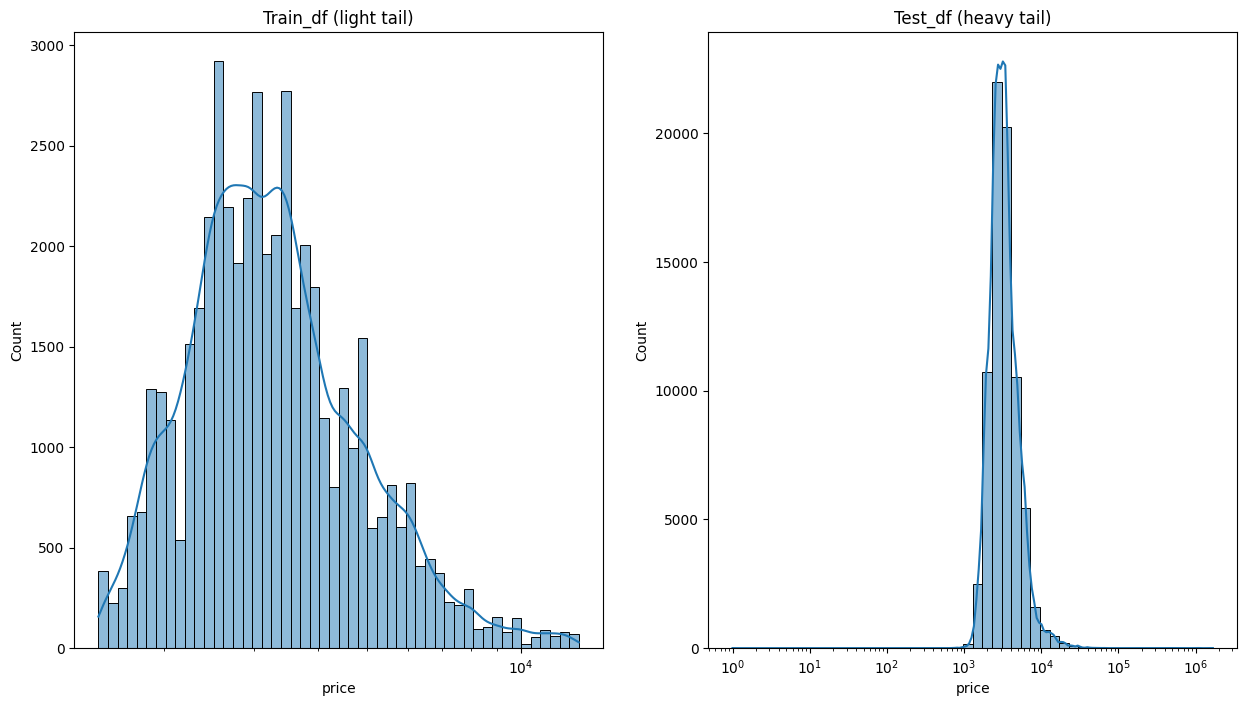

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
for num, df in enumerate([train_df, test_df]):
    sns.histplot(data=df, x="price", bins=50, ax=ax[num], log_scale=True, kde=True)
ax[0].set_title("Train_df (light tail)")
ax[1].set_title("Test_df (heavy tail)")
fig.show()

In [57]:
output_linreg_log(X_train=X_test, y_train=y_test, X_test=X_train, y_test=y_train)

for df in [test_df]:
    for column in [
        "price",
    ]:
        lower_limit = df[column].quantile(0.01)
        upper_limit = df[column].quantile(0.99)
        df.drop(
            df[(df[column] >= upper_limit) | (df[column] <= lower_limit)].index,
            inplace=True,
        )

X_test = test_df[new_feature_list]
y_test = test_df["price"]

# # Duan's smearing
# reg = LinearRegression()
# reg.fit(X_test, np.log1p(y_test))
# y_pred = reg.predict(X_test)
# residuals = np.log(y_test) - y_pred
# smearing_factor_ = np.mean(np.expm1(residuals))
# y_pred = np.expm1(y_pred + smearing_factor_)
# display(r_squared_score(y_test, y_pred))

,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,2028996.0771,717.7528,2825.8731,0.0502,N/a,N/a
1,LinReg_default,1000.9473,805.6489,0.2424,0.1109,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,554148274.4246,1066.4817,519603.1142,0.0502,N/a,N/a
1,LinReg_default,9594.8314,1096.8673,7.7475,0.1109,N/a,N/a


,model,train,test,diff,fit_time,iterations,convergence
0,TransformLog,-3254938726.3407,0.5476,-5943916917.7272,0.0502,N/a,N/a
1,LinReg_default,0.0242,0.5215,-0.9536,0.1109,N/a,N/a


\* if swap train and test transform would increase accuracy by ~0.02 r2

### 11.3 It will also be a useful exercise to implement a linear regression algorithm with batch and mini-batch training or analytical solution (as mentioned in 4.1).

implemented at 4.1 AS

*Sources:
- sklearn
- https://education.yandex.ru/handbook/ml/article/linear-models
- https://education.yandex.ru/handbook/ml/article/optimizaciya-v-ml
- https://www.dmitrymakarov.ru/learning/reg/ (diff implementation)
- https://data36.com/polynomial-regression-python-scikit-learn/ (poly, include_bias=False)
- https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/ 
- https://andrewpwheeler.com/2021/02/19/transforming-predicted-variables-in-regression/ (Duan's smearing)